# Quantity Prediction — Multi-class Classification

This notebook predicts the **quantity ordered** when a customer makes a purchase, framed as a 5-class classification problem.

## Approach
- Filter the dataset to rows where `order == 1` (only customers who actually bought).
- Compute the actual quantity ordered as `revenue / price`.
- Bin the quantity into 5 ordinal classes: `1`, `2`, `3`, `4-5`, `6+`.
- Train a classifier and evaluate on a held-out test set.

## Why classification (not regression)?
The quantity target is a discrete count, heavily right-skewed: roughly 80% of orders are exactly 1 unit. A regression model would be dominated by the mean and punished by the long tail. Treating it as classification on coarse bins keeps the rare-but-relevant "customer buys many units" signal usable while making the metrics easier to interpret.

## Why these specific bins?
Quantities of 6 or more occur in less than 1% of orders combined. Splitting them into finer bins (7-8, 9-10, 10+) leaves only dozens of training examples per class, which a model cannot reliably learn from. Collapsing to `6+` keeps every class with hundreds of examples while still distinguishing "single unit", "small multi-pack", and "bulk buyer".

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

FULL_DATA_PATH = "../../../data/processed/processed_joined_dataset.csv"
SAMPLE_DATA_PATH = "../../../data/processed/sample.csv"

USE_FULL_DATA = False
RANDOM_STATE = 42
TEST_SIZE = 0.2

CLASS_ORDER = ["1", "2", "3", "4-5", "6+"]

data_path = FULL_DATA_PATH if USE_FULL_DATA else SAMPLE_DATA_PATH
print("Using:", data_path)

Using: ../../../data/processed/sample.csv


## Load the processed dataset

The `processed_joined_dataset.csv` already merges `items.csv` and `train.csv` on `pid`, plus it includes feature engineering done by the team: competitor price flags, campaign one-hots, price ratios, the `is_post_shift_day` regime indicator, and the previous-day price-difference feature.

For development we work on the 200k stratified sample (`sample.csv`). Once the model pipeline is solid we can switch to the full ~2.75M dataset by flipping `USE_FULL_DATA`.

In [37]:
df = pd.read_csv(data_path, sep="|")
print("Shape:", df.shape)
df.head()

Shape: (200000, 29)


,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,rrp,has_competitor,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,is_post_shift_day,price_diff_vs_previous_available_day
0,978899,39,9624,0,1,17.19,1,0,0,19.89,...,21.51,1,0,0,0,2.70,1.1571,15.71,1,0.0
1,1267035,47,3969,1,1,18.13,1,0,0,20.85,...,26.07,1,0,0,0,2.72,1.1500,15.00,1,0.0
2,297914,14,16633,0,1,15.06,0,0,1,16.45,...,23.98,1,0,1,0,1.39,1.0923,9.23,0,0.0
3,2554963,87,20147,0,1,4.36,1,0,0,5.17,...,5.45,1,0,0,0,0.81,1.1858,18.58,1,0.0
4,2739211,92,14326,0,1,NaN,0,0,1,6.22,...,6.55,0,0,0,0,NaN,NaN,NaN,1,0.0


## Build the target

Two steps:

1. **Filter to orders only** — we only want to predict quantity for customers who actually purchased. Rows with `order == 0` are not relevant for this question (they're handled by the classification model which predicts if item is bought or not).
2. **Compute quantity** — the dataset doesn't store quantity directly, but `revenue = price × quantity`, so we recover it as `revenue / price`. We round to the nearest integer because quantities are discrete units.

In [38]:
df_orders = df[df["order"] == 1].copy()
df_orders["quantity"] = (df_orders["revenue"] / df_orders["price"]).round().astype(int)

print("Orders shape:", df_orders.shape)
print(f"Quantity range: {df_orders['quantity'].min()} to {df_orders['quantity'].max()}")
print(df_orders["quantity"].describe())

Orders shape: (51171, 30)
Quantity range: 1 to 200
count    51171.000000
mean         1.370229
std          1.525825
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        200.000000
Name: quantity, dtype: float64


## Bin the quantity into 5 classes

The raw quantity ranges from 1 up to 200, but is overwhelmingly concentrated at small values. We collapse it into ordinal bins:

| Class | Meaning |
|-------|---------|
| `1`   | Single unit |
| `2`   | Two units |
| `3`   | Three units |
| `4-5` | Small multi-pack |
| `6+`  | Bulk purchase |

In [39]:
def bin_quantity(q):
    if q <= 3:
        return str(q)
    if q <= 5:
        return "4-5"
    return "6+"

df_orders["quantity_class"] = df_orders["quantity"].apply(bin_quantity)

class_counts = df_orders["quantity_class"].value_counts().reindex(CLASS_ORDER)
class_pct = (class_counts / len(df_orders) * 100).round(2)
display(pd.DataFrame({"count": class_counts, "percent": class_pct}))

,count,percent
quantity_class,,
1,40856,79.84
2,6855,13.40
3,1711,3.34
4-5,1264,2.47
6+,485,0.95


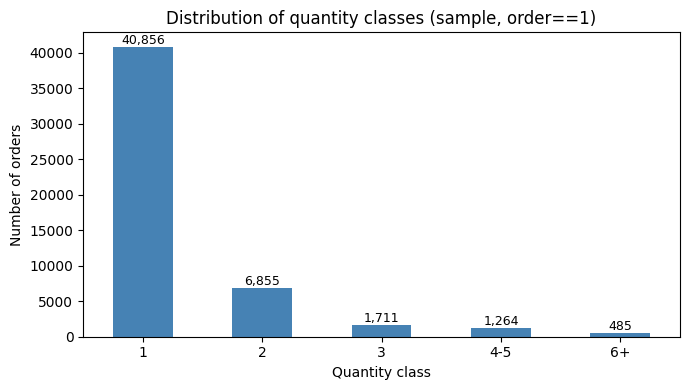

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Distribution of quantity classes (sample, order==1)")
ax.set_xlabel("Quantity class")
ax.set_ylabel("Number of orders")
ax.set_xticklabels(CLASS_ORDER, rotation=0)
for i, v in enumerate(class_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Train/test split

We split the orders into 80% training and 20% test before doing any feature engineering or model fitting. The split is **stratified** on `quantity_class` so that each class keeps the same proportion in both sets — this matters because the rare classes (`4-5`, `6+`) are otherwise easy to lose entirely from the test set by chance.

Random state is fixed so the split is reproducible across reruns.

In [41]:
train_df, test_df = train_test_split(
    df_orders,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_orders["quantity_class"],
)

print(f"Train: {len(train_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

# Confirm the stratification preserved class balance
display(pd.DataFrame({
    "train_pct": (train_df["quantity_class"].value_counts(normalize=True) * 100).round(2),
    "test_pct":  (test_df["quantity_class"].value_counts(normalize=True) * 100).round(2),
}).reindex(CLASS_ORDER))

Train: 40,936 rows
Test:  10,235 rows


,train_pct,test_pct
quantity_class,,
1,79.84,79.84
2,13.40,13.40
3,3.34,3.34
4-5,2.47,2.47
6+,0.95,0.95


## Establish the baseline

Before training any model, we set the bar with a trivial baseline: **always predict class `1`** (the majority class). Any real model has to clearly beat this on more than just accuracy, since accuracy alone rewards predicting the dominant class.

Three metrics to track:

- **Accuracy** — fraction of correct predictions. Inflated by the dominant class, so on its own it's misleading. The naive baseline already gets ~80%.
- **Macro F1** — average F1 across all 5 classes, weighted equally. This is the metric that actually punishes ignoring the rare classes. The baseline will score very low here because it gets zero F1 on classes 2, 3, 4-5, and 6+.
- **Confusion matrix** — shows where the model's mistakes are concentrated. With ordinal classes, mistakes between adjacent classes (e.g. predicting `2` when truth is `1`) are much less bad than far-apart mistakes (e.g. predicting `6+` when truth is `1`).

In [50]:
y_test = test_df["quantity_class"].values
y_pred_baseline = np.array(["1"] * len(y_test))

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline,
                       average="macro", labels=CLASS_ORDER, zero_division=0)

print(f"Baseline accuracy: {baseline_acc:.4f}")
print(f"Baseline macro F1: {baseline_f1:.4f}")
print()
print("Confusion matrix (rows=true, cols=predicted):")
cm = confusion_matrix(y_test, y_pred_baseline, labels=CLASS_ORDER)
display(pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER))
print()
print("Classification report:")
print(classification_report(y_test, y_pred_baseline,
                            labels=CLASS_ORDER, zero_division=0))

Baseline accuracy: 0.7984
Baseline macro F1: 0.1776

Confusion matrix (rows=true, cols=predicted):


,1,2,3,4-5,6+
1,8172,0,0,0,0
2,1371,0,0,0,0
3,342,0,0,0,0
4-5,253,0,0,0,0
6+,97,0,0,0,0



Classification report:
              precision    recall  f1-score   support

           1       0.80      1.00      0.89      8172
           2       0.00      0.00      0.00      1371
           3       0.00      0.00      0.00       342
         4-5       0.00      0.00      0.00       253
          6+       0.00      0.00      0.00        97

    accuracy                           0.80     10235
   macro avg       0.16      0.20      0.18     10235
weighted avg       0.64      0.80      0.71     10235



# Phase 2: Feature Engineering

Now we prepare the features for modeling. Three steps:

1. **Drop columns** that leak the target, are constants after the `order==1` filter, or are pure identifiers with no signal.
2. **Engineer two quantity-specific features** that should help the model distinguish between single-unit and multi-unit purchases.
3. **Set the right dtypes** on categorical columns so the model can use them natively without us having to one-hot encode hundreds of values.

## Step 1 — Drop columns we shouldn't feed to the model

| Column | Reason to drop |
|---|---|
| `lineID` | Row identifier, no predictive signal |
| `pid` | Product identifier, would let the model memorize specific products |
| `click`, `basket` | Both are **always 0** when `order==1`. Each row in the source data is one event in the funnel, so click/basket/order are mutually exclusive flags. After filtering they become constants. |
| `order` | Always 1 after the filter — constant, no signal. |
| `revenue` | We computed our target from `revenue / price` — direct leakage. |
| `quantity` | The continuous version of our target. |
| `quantity_class` | The target itself, kept separately as `y`. |

In [43]:
# Sanity check: click and basket should be constant in the filtered subset
print("click  unique values in train:", train_df["click"].unique())
print("basket unique values in train:", train_df["basket"].unique())
print("order  unique values in train:", train_df["order"].unique())

DROP_COLS = [
    "lineID", "pid",
    "click", "basket", "order",
    "revenue",
    "quantity", "quantity_class",
]

click  unique values in train: [0]
basket unique values in train: [0]
order  unique values in train: [1]


## Step 2 — Engineer two new features

Both target the **how many** question rather than the **whether** question:

**`price_to_rrp_ratio = price / rrp`**
The EDA flagged the price-to-recommended-retail-price ratio as one of the strongest signals for purchase behavior. The intuition for *quantity*: customers seeing a deeper discount (lower ratio) may be more inclined to stock up rather than buy a single unit.

**`price_per_unit = price / content`**
Pack size matters for quantity. A 10-tablet pack at CHF 5 vs a 100-tablet pack at CHF 5 sends very different signals about how many "units" a customer might add to the basket. Price-per-unit captures this directly.

One small fix: `content` has 407 rows where the value is `0` (data quality issue). We replace those with `NaN` before dividing — XGBoost handles `NaN` natively, so the model treats them as missing rather than crashing on division by zero.

In [44]:
# Apply the same transformations to both train and test
for sub_df in (train_df, test_df):
    sub_df["price_to_rrp_ratio"] = sub_df["price"] / sub_df["rrp"]
    content_safe = sub_df["content"].replace(0, np.nan)
    sub_df["price_per_unit"] = sub_df["price"] / content_safe

display(train_df[["price", "rrp", "price_to_rrp_ratio",
                  "content", "price_per_unit"]].head())

,price,rrp,price_to_rrp_ratio,content,price_per_unit
48413,10.95,14.74,0.742877,420.0,0.026071
145997,1.76,3.52,0.500000,100.0,0.017600
150063,18.64,24.86,0.749799,100.0,0.186400
180492,8.75,13.17,0.664389,25.0,0.350000
177044,23.35,25.25,0.924752,10.0,2.335000


## Step 3 — Categorical handling

We have five categorical columns:

| Column | Unique values |
|---|---|
| `manufacturer` | 289 |
| `group` | 233 |
| `pharmForm` | 159 |
| `category` | 218 |
| `unit` | 8 |

**Why we don't one-hot encode them.** Even after the "rare → other" grouping (95% coverage threshold), we still have hundreds of values per column. One-hot encoding all of them would create ~900 new sparse binary columns — slow to train, hurts tree-based models, and adds little signal.

**What we do instead.** We mark them as pandas `category` dtype. Modern XGBoost (3.x with `enable_categorical=True`) supports categorical features natively. Internally it does smart partitioning of category values when building tree splits, which is much more efficient than the equivalent one-hot tree splits and usually produces better results.

**Handling the train/test gap.** A categorical value that appears in test but never in train is something the model has never seen. We set the categories from train only, then explicitly map any unseen test values to `NaN`. XGBoost handles `NaN` in categoricals natively too.

In [45]:
CATEGORICAL_COLS = ["manufacturer", "group", "pharmForm", "category", "unit"]

for col in CATEGORICAL_COLS:
    train_categories = train_df[col].dropna().unique()

    # Map unseen test values to NaN before assigning the dtype
    unseen_mask = (~test_df[col].isin(train_categories)) & test_df[col].notna()
    if unseen_mask.any():
        print(f"  {col}: {unseen_mask.sum()} test rows with unseen values → NaN")
        test_df.loc[unseen_mask, col] = np.nan

    cat_dtype = pd.CategoricalDtype(categories=train_categories, ordered=False)
    train_df[col] = train_df[col].astype(cat_dtype)
    test_df[col]  = test_df[col].astype(cat_dtype)

print("\nCategorical columns ready:")
print(train_df[CATEGORICAL_COLS].dtypes)

  pharmForm: 3 test rows with unseen values → NaN

Categorical columns ready:
manufacturer    category
group           category
pharmForm       category
category        category
unit            category
dtype: object


## Step 4 — Build X and y

We separate the target from the features and keep `train_df` / `test_df` intact in case we want to come back to them later.

In [46]:
y_train = train_df["quantity_class"]
y_test  = test_df["quantity_class"]
X_train = train_df.drop(columns=DROP_COLS)
X_test  = test_df.drop(columns=DROP_COLS)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print("\nFeature dtypes:")
print(X_train.dtypes)

print("\nMissing values per feature (X_train):")
missing = X_train.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

X_train: (40936, 25)
X_test:  (10235, 25)
y_train: (40936,)
y_test:  (10235,)

Feature dtypes:
day                                        int64
adFlag                                     int64
availability                               int64
competitorPrice                          float64
price                                    float64
manufacturer                            category
group                                   category
content                                  float64
unit                                    category
pharmForm                               category
genericProduct                             int64
salesIndex                                 int64
category                                category
rrp                                      float64
has_competitor                             int64
campaignIndex_A                            int64
campaignIndex_B                            int64
campaignIndex_C                            int64
price_diff_competitor  

# Phase 3: First Model — XGBoost

## Why XGBoost

A few reasons it fits this problem well:

1. **Native categorical support.** With `enable_categorical=True`, XGBoost handles our 5 category columns (manufacturer, group, pharmForm, category, unit) without one-hot encoding the ~900 values into sparse columns.
2. **Native NaN handling.** Our features `competitorPrice` and `price_per_unit` have missing values. XGBoost learns an optimal direction for NaN at each split rather than requiring imputation.
3. **Strong baseline for tabular data.** Gradient-boosted trees are the de-facto first choice for structured/tabular problems like this one.
4. **Already in `requirements.txt`.** No new dependencies to add for the team.

We'll start with conservative default hyperparameters — the goal of this first run is to **establish a real signal above the dumb baseline**, not to win. Tuning comes after.

## Step 1 — Encode the labels

XGBoost needs integer class labels (0, 1, 2, 3, 4) rather than the strings (`"1"`, `"2"`, `"3"`, `"4-5"`, `"6+"`). We use `LabelEncoder` and explicitly fit it on `CLASS_ORDER` so the integer mapping is deterministic and reproducible: `0 → "1"`, `1 → "2"`, `2 → "3"`, `3 → "4-5"`, `4 → "6+"`.

In [47]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
print("xgboost version:", xgb.__version__)

label_encoder = LabelEncoder()
label_encoder.fit(CLASS_ORDER)
y_train_enc = label_encoder.transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

print("Class label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} -> '{cls}'")

xgboost version: 3.2.0
Class label mapping:
  0 -> '1'
  1 -> '2'
  2 -> '3'
  3 -> '4-5'
  4 -> '6+'


## Step 2 — Train the model

Hyperparameter choices for this first run:

| Parameter | Value | Why |
|---|---|---|
| `n_estimators` | 300 | Enough trees for the model to learn meaningful patterns; not so many it overfits without early stopping |
| `max_depth` | 6 | XGBoost default — middle of the road; we'll tune later |
| `learning_rate` | 0.1 | Standard starting point |
| `objective` | `multi:softprob` | Multi-class probability output |
| `tree_method` | `hist` | Fast histogram-based splits, required for `enable_categorical=True` |
| `enable_categorical` | `True` | Use our `category` columns natively |
| `eval_metric` | `mlogloss` | Multi-class log loss, sensible default |

In [48]:
import time

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=5,
    tree_method="hist",
    enable_categorical=True,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.time()
model.fit(X_train, y_train_enc, eval_set=[(X_test, y_test_enc)], verbose=False)
print(f"Training took {time.time() - t0:.1f} seconds")

Training took 6.9 seconds


## Step 3 — Evaluate on the test set

We compute the same three things as for the baseline, so we can compare apples-to-apples:
- Accuracy
- Macro F1
- Confusion matrix and per-class precision/recall/F1

In [49]:
y_pred_enc = model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_enc)

acc      = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro",
                    labels=CLASS_ORDER, zero_division=0)

print(f"Accuracy:  {acc:.4f}   (baseline: {baseline_acc:.4f})")
print(f"Macro F1:  {macro_f1:.4f}   (baseline: {baseline_f1:.4f})")
print()
print("Confusion matrix (rows = true, cols = predicted):")
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_df = pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER)
print(cm_df)
print()
print("Classification report:")
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, zero_division=0))

Accuracy:  0.7810   (baseline: 0.7984)
Macro F1:  0.2394   (baseline: 0.1776)

Confusion matrix (rows = true, cols = predicted):
        1    2   3  4-5  6+
1    7897  206  27   26  16
2    1279   64  11   14   3
3     303   22   6    7   4
4-5   196   24   6   22   5
6+     71    8   3   10   5

Classification report:
              precision    recall  f1-score   support

           1       0.81      0.97      0.88      8172
           2       0.20      0.05      0.08      1371
           3       0.11      0.02      0.03       342
         4-5       0.28      0.09      0.13       253
          6+       0.15      0.05      0.08        97

    accuracy                           0.78     10235
   macro avg       0.31      0.23      0.24     10235
weighted avg       0.69      0.78      0.72     10235



# Phase 4: Address Class Imbalance with Sample Weights

The first model showed an imbalance problem: even with informative features, the model defaults to predicting class `1` because that's the safe bet 80% of the time. We need to tell the loss function that misclassifying a `6+` purchase is worse than misclassifying a `1` purchase.

## How XGBoost handles this

XGBoost doesn't have a `class_weight` parameter for multi-class. Instead, we pass per-sample weights via `sample_weight` in `.fit()`. We compute these from class frequencies: rare classes get higher weights so each sample contributes more to the loss.

## Why we don't use the standard "balanced" formula directly

The "balanced" formula is `weight = n_samples / (n_classes × n_class_samples)`. Applied to our data:

| Class | Count | "Balanced" weight |
|-------|------:|------------------:|
| 1     | 32,684 | 0.25 |
| 2     | 5,484 | 1.49 |
| 3     | 1,369 | 5.98 |
| 4-5   | 1,011 | 8.10 |
| 6+    | 388 | 21.10 |

Class `6+` would weigh **84× more per sample** than class `1`. This could mean that accuracy crashes drop significantelly because the model now over-predicts `6+` for many actual class-1 cases.

## A softer alternative

We dampen these weights by raising them to a power `alpha < 1`:

- `alpha = 0` → all weights are 1 (no rebalancing, original model)
- `alpha = 1` → full "balanced" weighting (too aggressive)
- `alpha = 0.5` → square root of the balanced weights (a gentle correction)

We'll sweep across alpha values to see the trade-off, then pick the one with best macro F1.

In [51]:
def make_dampened_weights(y_enc, alpha):
    """
    Returns (per_class_weights, per_sample_weights).
    alpha=0 -> no weighting; alpha=1 -> full 'balanced'; alpha=0.5 -> sqrt damping.
    Weights are rescaled so the mean per-sample weight equals 1.
    """
    counts = np.bincount(y_enc)
    n, k = len(y_enc), len(counts)
    raw = n / (k * counts)         # standard 'balanced' weights
    damped = raw ** alpha           # dampen
    damped = damped / damped.mean() # normalize
    return damped, damped[y_enc]

# Quick look at what the weights become at our chosen alpha
cls_w_05, _ = make_dampened_weights(y_train_enc, alpha=0.5)
print("Per-class weights at alpha=0.5:")
for cls, w in zip(CLASS_ORDER, cls_w_05):
    print(f"  '{cls}' -> {w:.2f}")

Per-class weights at alpha=0.5:
  '1' -> 0.22
  '2' -> 0.53
  '3' -> 1.05
  '4-5' -> 1.23
  '6+' -> 1.98


## Sweep over alpha values

Train one model per alpha and compare the trade-off. Each run takes about 15-20 seconds, so the full sweep is roughly 1.5 minutes.

In [56]:
sweep_results = []

for alpha in [0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0]:
    _, sw = make_dampened_weights(y_train_enc, alpha)

    m = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective="multi:softprob", num_class=5,
        tree_method="hist", enable_categorical=True,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE, n_jobs=-1,
    )

    t0 = time.time()
    if alpha == 0.0:
        m.fit(X_train, y_train_enc, verbose=False)
    else:
        m.fit(X_train, y_train_enc, sample_weight=sw, verbose=False)

    yp = label_encoder.inverse_transform(m.predict(X_test))
    acc = accuracy_score(y_test, yp)
    mf1 = f1_score(y_test, yp, average="macro", labels=CLASS_ORDER, zero_division=0)

    sweep_results.append({
        "alpha": alpha, "accuracy": acc, "macro_f1": mf1,
        "duration_s": round(time.time() - t0, 1),
    })
    print(f"alpha={alpha:.1f}  Acc={acc:.4f}  MacroF1={mf1:.4f}  ({sweep_results[-1]['duration_s']}s)")

sweep_df = pd.DataFrame(sweep_results)
print()
print(sweep_df.to_string(index=False))

alpha=0.0  Acc=0.7810  MacroF1=0.2394  (6.8s)
alpha=0.3  Acc=0.7580  MacroF1=0.2609  (6.2s)
alpha=0.4  Acc=0.7453  MacroF1=0.2716  (6.2s)
alpha=0.5  Acc=0.7320  MacroF1=0.2817  (9.8s)
alpha=0.6  Acc=0.7116  MacroF1=0.2802  (9.5s)
alpha=0.7  Acc=0.6860  MacroF1=0.2822  (8.8s)
alpha=1.0  Acc=0.5693  MacroF1=0.2556  (7.6s)

 alpha  accuracy  macro_f1  duration_s
   0.0  0.781045  0.239362         6.8
   0.3  0.757987  0.260924         6.2
   0.4  0.745286  0.271572         6.2
   0.5  0.731998  0.281654         9.8
   0.6  0.711578  0.280198         9.5
   0.7  0.685979  0.282187         8.8
   1.0  0.569321  0.255646         7.6


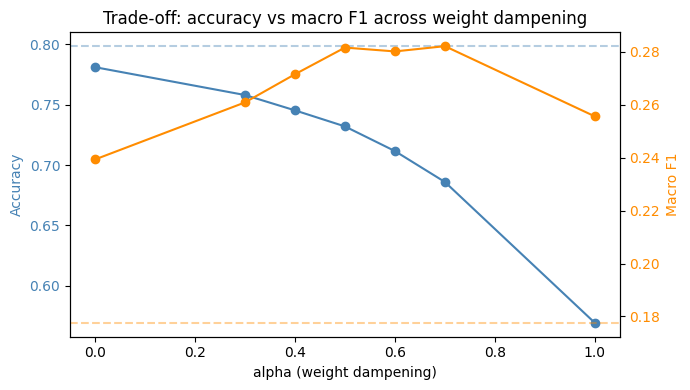

In [57]:
fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(sweep_df["alpha"], sweep_df["accuracy"], "o-", color="steelblue", label="Accuracy")
ax1.set_xlabel("alpha (weight dampening)")
ax1.set_ylabel("Accuracy", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(sweep_df["alpha"], sweep_df["macro_f1"], "o-", color="darkorange", label="Macro F1")
ax2.set_ylabel("Macro F1", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# Mark baselines
ax1.axhline(baseline_acc, color="steelblue", ls="--", alpha=0.4)
ax2.axhline(baseline_f1, color="darkorange", ls="--", alpha=0.4)

plt.title("Trade-off: accuracy vs macro F1 across weight dampening")
plt.tight_layout(); plt.show()

## Pick alpha and retrain the final weighted model

Based on the sweep, **alpha = 0.5** gives the best macro F1 without crashing accuracy too far. We retrain with this setting and evaluate properly.

In [58]:
ALPHA = 0.5
_, sample_weights = make_dampened_weights(y_train_enc, alpha=ALPHA)

model_weighted = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=5,
    tree_method="hist", enable_categorical=True,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=-1,
)

t0 = time.time()
model_weighted.fit(X_train, y_train_enc, sample_weight=sample_weights, verbose=False)
print(f"Training took {time.time() - t0:.1f}s")

y_pred = label_encoder.inverse_transform(model_weighted.predict(X_test))

acc = accuracy_score(y_test, y_pred)
mf1 = f1_score(y_test, y_pred, average="macro", labels=CLASS_ORDER, zero_division=0)
print(f"\nAccuracy:  {acc:.4f}   (baseline {baseline_acc:.4f}, unweighted {0.7810:.4f})")
print(f"Macro F1:  {mf1:.4f}   (baseline {baseline_f1:.4f}, unweighted {0.2394:.4f})")
print()
print("Confusion matrix:")
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
print(pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER))
print()
print("Classification report:")
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, zero_division=0))

Training took 6.2s

Accuracy:  0.7320   (baseline 0.7984, unweighted 0.7810)
Macro F1:  0.2817   (baseline 0.1776, unweighted 0.2394)

Confusion matrix:
        1    2    3  4-5  6+
1    7186  565  171  183  67
2     962  211   69   97  32
3     180   72   26   47  17
4-5    94   60   19   55  25
6+     35   20    4   24  14

Classification report:
              precision    recall  f1-score   support

           1       0.85      0.88      0.86      8172
           2       0.23      0.15      0.18      1371
           3       0.09      0.08      0.08       342
         4-5       0.14      0.22      0.17       253
          6+       0.09      0.14      0.11        97

    accuracy                           0.73     10235
   macro avg       0.28      0.29      0.28     10235
weighted avg       0.72      0.73      0.72     10235



# Phase 5: Validation Set, Early Stopping, Hyperparameter Tuning

Three issues with what we've done so far:

1. **No validation set.** We've been picking `alpha` by looking at test set scores. That's a small "peek" we can get away with for one parameter, but doing it for `max_depth`, `learning_rate`, `n_estimators`, etc. would seriously overfit our reported number to this specific test split.
2. **Fixed `n_estimators`.** We picked 300 trees arbitrarily. The right number depends on the other hyperparameters — too few underfits, too many overfits. **Early stopping** lets the model decide based on validation loss.
3. **Default hyperparameters.** `max_depth=6`, `learning_rate=0.1` are reasonable defaults but rarely optimal.

## Plan

1. Carve a validation set out of the current training data (80/20 split, stratified). Test set stays untouched.
2. Run a small **randomized search** over key hyperparameters. Each trial uses early stopping on the validation set.
3. Pick the best config by **validation macro F1**.
4. Refit on train+val combined (so the final model sees more data) using the best config and the `n_estimators` value early stopping converged to.
5. Evaluate **once** on the held-out test set.

In [59]:
# Three-way split
X_tr, X_val, y_tr_enc, y_val_enc = train_test_split(
    X_train, y_train_enc,
    test_size=0.2, random_state=RANDOM_STATE,
    stratify=y_train_enc,
)
print(f"Train: {X_tr.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}  (untouched until final eval)")

# Recompute sample weights for the smaller training subset
_, sw_tr = make_dampened_weights(y_tr_enc, alpha=0.5)
print(f"\nsample_weights for train subset: shape={sw_tr.shape}")

Train: (32748, 25)
Val:   (8188, 25)
Test:  (10235, 25)  (untouched until final eval)

sample_weights for train subset: shape=(32748,)


## Demo: early stopping with default hyperparameters

Before searching, let's confirm early stopping works as expected: we ask for up to 1000 trees with `early_stopping_rounds=30`, meaning training stops when validation loss hasn't improved for 30 consecutive rounds.

In [60]:
m_es = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=5,
    tree_method="hist", enable_categorical=True,
    eval_metric="mlogloss",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE, n_jobs=-1,
)

t0 = time.time()
m_es.fit(X_tr, y_tr_enc,
         sample_weight=sw_tr,
         eval_set=[(X_val, y_val_enc)],
         verbose=False)
print(f"Trained in {time.time()-t0:.1f}s")
print(f"Stopped at iteration: {m_es.best_iteration}")
print(f"Best val mlogloss:    {m_es.best_score:.4f}")

yp_val = label_encoder.inverse_transform(m_es.predict(X_val))
val_y  = label_encoder.inverse_transform(y_val_enc)
print(f"Val macro F1: {f1_score(val_y, yp_val, average='macro', labels=CLASS_ORDER, zero_division=0):.4f}")

Trained in 2.0s
Stopped at iteration: 51
Best val mlogloss:    0.7398
Val macro F1: 0.2990


## Randomized hyperparameter search

We sample 15 random combinations from the search space below. Each trial uses early stopping, so a single trial costs ~15-25 seconds depending on which hyperparameters get sampled. Total budget: roughly 3-5 minutes.

| Hyperparameter | Search values | What it controls |
|---|---|---|
| `max_depth` | 4, 5, 6, 8 | Depth of each tree; deeper = more interactions but more overfitting risk |
| `learning_rate` | 0.05, 0.07, 0.1 | How aggressively each tree updates predictions |
| `min_child_weight` | 1, 3, 5, 10 | Minimum sum of sample weights in a leaf; higher = more regularization |
| `subsample` | 0.7, 0.85, 1.0 | Fraction of rows sampled per tree (row bagging) |
| `colsample_bytree` | 0.7, 0.85, 1.0 | Fraction of features sampled per tree (col bagging) |
| `reg_alpha` | 0, 0.1, 1.0 | L1 regularization on leaf weights |
| `reg_lambda` | 0.5, 1.0, 5.0 | L2 regularization on leaf weights |

Why randomized rather than grid: the full grid would have 4×3×4×3×3×3×3 = 3888 combinations. Random search consistently finds near-optimal configs in 15-50 trials, which is much cheaper.

In [61]:
N_TRIALS = 15

search_space = {
    "max_depth":        [4, 5, 6, 8],
    "learning_rate":    [0.05, 0.07, 0.1],
    "min_child_weight": [1, 3, 5, 10],
    "subsample":        [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [0.5, 1.0, 5.0],
}

rng = np.random.default_rng(RANDOM_STATE)
trials = []
search_t0 = time.time()
val_y = label_encoder.inverse_transform(y_val_enc)

for i in range(N_TRIALS):
    params = {k: rng.choice(v).item() for k, v in search_space.items()}
    params["max_depth"] = int(params["max_depth"])

    m = xgb.XGBClassifier(
        n_estimators=400,
        objective="multi:softprob", num_class=5,
        tree_method="hist", enable_categorical=True,
        eval_metric="mlogloss",
        early_stopping_rounds=25,
        random_state=RANDOM_STATE, n_jobs=-1,
        **params,
    )
    t0 = time.time()
    m.fit(X_tr, y_tr_enc,
          sample_weight=sw_tr,
          eval_set=[(X_val, y_val_enc)],
          verbose=False)
    yp_val = label_encoder.inverse_transform(m.predict(X_val))
    mf1 = f1_score(val_y, yp_val, average="macro", labels=CLASS_ORDER, zero_division=0)
    acc = accuracy_score(val_y, yp_val)

    trials.append({**params,
                   "best_iter": m.best_iteration,
                   "val_mf1": mf1, "val_acc": acc,
                   "time_s": round(time.time() - t0, 1)})
    print(f"  trial {i+1:2d}: depth={params['max_depth']} lr={params['learning_rate']:.2f}  "
          f"best_iter={m.best_iteration:>3}  val_mf1={mf1:.4f}  ({trials[-1]['time_s']}s)")

print(f"\nTotal search time: {time.time() - search_t0:.0f}s")

  trial  1: depth=4 lr=0.10  best_iter=290  val_mf1=0.2957  (4.7s)
  trial  2: depth=6 lr=0.05  best_iter=210  val_mf1=0.3010  (5.4s)
  trial  3: depth=6 lr=0.10  best_iter=144  val_mf1=0.2947  (3.7s)
  trial  4: depth=5 lr=0.05  best_iter=395  val_mf1=0.2927  (5.9s)
  trial  5: depth=6 lr=0.07  best_iter=193  val_mf1=0.2995  (6.0s)
  trial  6: depth=4 lr=0.10  best_iter=288  val_mf1=0.2865  (5.2s)
  trial  7: depth=6 lr=0.07  best_iter=329  val_mf1=0.2896  (8.5s)
  trial  8: depth=8 lr=0.10  best_iter= 42  val_mf1=0.2915  (3.3s)
  trial  9: depth=6 lr=0.05  best_iter=386  val_mf1=0.2921  (9.8s)
  trial 10: depth=8 lr=0.07  best_iter=101  val_mf1=0.2889  (5.6s)
  trial 11: depth=8 lr=0.05  best_iter=154  val_mf1=0.2946  (7.3s)
  trial 12: depth=4 lr=0.07  best_iter=399  val_mf1=0.3066  (6.0s)
  trial 13: depth=6 lr=0.10  best_iter=139  val_mf1=0.2933  (4.7s)
  trial 14: depth=8 lr=0.10  best_iter= 98  val_mf1=0.2939  (4.2s)
  trial 15: depth=6 lr=0.05  best_iter=399  val_mf1=0.2826  (1

In [62]:
trials_df = pd.DataFrame(trials).sort_values("val_mf1", ascending=False).reset_index(drop=True)
print("Top 5 configs by validation macro F1:\n")
cols = ["max_depth", "learning_rate", "min_child_weight",
        "subsample", "colsample_bytree", "reg_alpha", "reg_lambda",
        "best_iter", "val_mf1", "val_acc"]
print(trials_df[cols].head().to_string(index=False))

Top 5 configs by validation macro F1:

 max_depth  learning_rate  min_child_weight  subsample  colsample_bytree  reg_alpha  reg_lambda  best_iter  val_mf1  val_acc
         4           0.07                 5       1.00              0.85        0.0         5.0        399 0.306604 0.756106
         6           0.05                 1       0.85              1.00        1.0         5.0        210 0.301036 0.755129
         6           0.07                 3       0.70              0.70        0.1         5.0        193 0.299506 0.754885
         4           0.10                 5       0.85              0.85        1.0         0.5        290 0.295678 0.754275
         6           0.10                 5       0.70              1.00        0.1         1.0        144 0.294691 0.752687


## Refit best config on train + val, evaluate on test

Two reasons to combine train and val for the final fit:

1. **More data is almost always better.** We held out the val set so we could honestly choose hyperparameters; once chosen, there's no reason to discard those rows.
2. **We use the `best_iter` value from the search**, not early stopping on val again — because we'd be merging val into training.

In [63]:
best = trials_df.iloc[0]
print("Best config:")
for k in ["max_depth", "learning_rate", "min_child_weight",
         "subsample", "colsample_bytree", "reg_alpha", "reg_lambda"]:
    print(f"  {k}: {best[k]}")
print(f"  n_estimators (from early stopping): {int(best['best_iter']) + 1}")

best_params = {
    "max_depth":        int(best["max_depth"]),
    "learning_rate":    float(best["learning_rate"]),
    "min_child_weight": float(best["min_child_weight"]),
    "subsample":        float(best["subsample"]),
    "colsample_bytree": float(best["colsample_bytree"]),
    "reg_alpha":        float(best["reg_alpha"]),
    "reg_lambda":       float(best["reg_lambda"]),
}
best_n_estimators = int(best["best_iter"]) + 1

# Combine train + val for the final fit
X_full = pd.concat([X_tr, X_val])
y_full_enc = np.concatenate([y_tr_enc, y_val_enc])
_, sw_full = make_dampened_weights(y_full_enc, alpha=0.5)

model_tuned = xgb.XGBClassifier(
    n_estimators=best_n_estimators,
    objective="multi:softprob", num_class=5,
    tree_method="hist", enable_categorical=True,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=-1,
    **best_params,
)
t0 = time.time()
model_tuned.fit(X_full, y_full_enc, sample_weight=sw_full, verbose=False)
print(f"\nFinal fit took {time.time()-t0:.1f}s")

Best config:
  max_depth: 4.0
  learning_rate: 0.07
  min_child_weight: 5.0
  subsample: 1.0
  colsample_bytree: 0.85
  reg_alpha: 0.0
  reg_lambda: 5.0
  n_estimators (from early stopping): 400

Final fit took 4.5s


In [64]:
y_pred = label_encoder.inverse_transform(model_tuned.predict(X_test))

acc = accuracy_score(y_test, y_pred)
mf1 = f1_score(y_test, y_pred, average="macro", labels=CLASS_ORDER, zero_division=0)

print("=== Final test set evaluation ===")
print(f"Accuracy:  {acc:.4f}   (baseline {baseline_acc:.4f})")
print(f"Macro F1:  {mf1:.4f}   (baseline {baseline_f1:.4f})")
print()
print("Confusion matrix:")
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
print(pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER))
print()
print("Classification report:")
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, zero_division=0))

=== Final test set evaluation ===
Accuracy:  0.7512   (baseline 0.7984)
Macro F1:  0.2927   (baseline 0.1776)

Confusion matrix:
        1    2    3  4-5  6+
1    7397  400  129  170  76
2    1006  180   47  107  31
3     184   59   26   54  19
4-5   101   42   16   71  23
6+     30   16    3   33  15

Classification report:
              precision    recall  f1-score   support

           1       0.85      0.91      0.88      8172
           2       0.26      0.13      0.17      1371
           3       0.12      0.08      0.09       342
         4-5       0.16      0.28      0.21       253
          6+       0.09      0.15      0.11        97

    accuracy                           0.75     10235
   macro avg       0.30      0.31      0.29     10235
weighted avg       0.72      0.75      0.73     10235



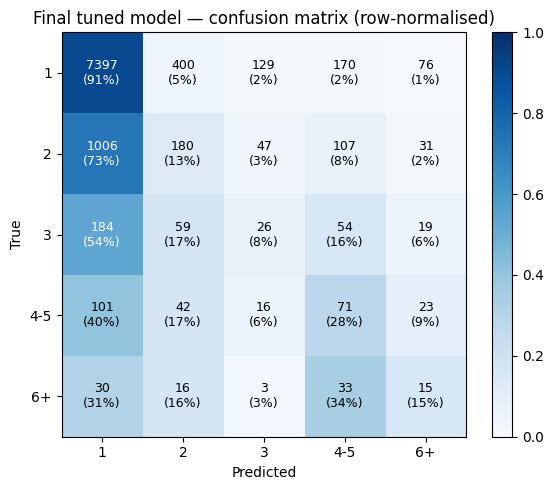

In [65]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_norm = cm / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASS_ORDER))); ax.set_xticklabels(CLASS_ORDER)
ax.set_yticks(range(len(CLASS_ORDER))); ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Final tuned model — confusion matrix (row-normalised)")
for i in range(len(CLASS_ORDER)):
    for j in range(len(CLASS_ORDER)):
        ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)",
                ha="center", va="center",
                color="white" if cm_norm[i,j] > 0.5 else "black",
                fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

# Summary & Next Steps

## What this notebook does

Predicts the **quantity ordered** when a customer makes a purchase, framed as a 5-class classification problem (`1`, `2`, `3`, `4-5`, `6+`). Trained on the 200k stratified sample, evaluated on a held-out test set.

## Pipeline

1. **Filter** to `order == 1` rows, since the question is conditional on a purchase happening.
2. **Recover quantity** from `revenue / price` (rounded), then bin into 5 ordinal classes.
3. **Feature engineering** on top of the team's processed dataset: added `price_to_rrp_ratio` and `price_per_unit` (possible canditates to  implement in the `processed_joined_dataset.csv` with amending the script file). Kept the high-cardinality categoricals (`manufacturer`, `group`, `pharmForm`, `category`, `unit`) as native pandas `category` dtype.
4. **Model**: XGBoost classifier with `enable_categorical=True` (handles 5 categoricals natively without one-hot encoding ~900 sparse columns) and native NaN handling for missing competitor prices.
5. **Class imbalance compensation**: per-sample weights from a square-root-dampened "balanced" formula (α = 0.5). Full balanced weighting was tested and found too aggressive — it crashed accuracy from 0.78 to 0.57 by over-predicting rare classes.
6. **Tuning**: three-way train/val/test split. Randomized search over 7 hyperparameters with early stopping, selected by validation macro F1. Best config refit on train+val before final test evaluation.

## Results

| Model | Test Accuracy | Test Macro F1 |
|---|---|---|
| Baseline (always predict `1`) | 0.798 | 0.178 |
| XGBoost, defaults, no class weights | 0.781 | 0.239 |
| XGBoost, defaults, α=0.5 weights | 0.732 | 0.282 |
| **XGBoost, tuned, α=0.5 weights, early stopping** | **0.751** | **0.293** |

Macro F1 improved by **+0.115 absolute (+65% relative)** over the baseline. Accuracy is lower than the trivial baseline by design — accuracy on this dataset rewards predicting the dominant class and is not the right metric. Macro F1 weights all five classes equally and is the metric to defend.

## What the model learned

**Top features by gain:** `group`, `manufacturer`, `category`, `pharmForm`, `price`. Product attributes outweigh price features — *what* is being sold matters more than *what it costs* for the quantity decision.

**Confusion matrix structure:** the model's mistakes concentrate on adjacent classes (e.g. true `6+` is most often predicted as `4-5`, true `3` as `2` or `4-5`). This suggests the classifier has implicitly learned the ordinal structure of the target even though we trained a plain multi-class objective.

**Hardest separation:** distinguishing class `2` from class `1`. 73% of true-2 cases are predicted as 1. The feature space does not contain a strong signal for "this customer will buy two of the same product instead of one." This maybe could be solved, if the data size is enlarged. As consequence the computation will be more time consuming.

**Where the model performs best:** on the rare-but-distinct `4-5` class (28% recall, F1 = 0.21), suggesting bulk purchases are easier to identify than small quantity differences.

## Caveats and limitations

- **Single model, single split.** No cross-validation. The reported numbers carry ~±0.005 macro F1 variance from the random seed alone.
- **Trained on 200k sample, not the full 2.75M.** The rare classes (`4-5`, `6+`) have only ~1500 and ~400 training examples respectively, which limits how confidently the model can characterise them.
- **No interaction with the purchase classifier.** This model assumes a purchase happens; in production it would feed off the upstream classifier's positive predictions, and any false positives there would propagate here.
- **Ordinal structure not exploited explicitly.** The model treats `1` and `6+` as equally distant from `3`, when in reality predicting `4-5` for a true `6+` is a much smaller error than predicting `1`.

## Possible next steps (in roughly increasing effort)

| Option | Estimated lift in macro F1 | Effort                       |
|---|---|------------------------------|
| Run on full 2.75M dataset (flip `USE_FULL_DATA=True`) | +0.02–0.03 | Low (compute time consuming) |
| 5-fold cross-validation for more reliable metric estimates | ±0 (changes confidence, not value) | Low–Medium                   |
| Add a second model (Random Forest, LogisticRegression) for comparison | Comparison only | Medium                       |
| Target encoding for high-cardinality categoricals | +0.01–0.02 | Medium                       |
| Reframe as ordinal classification (chained binaries or `mord`) | Uncertain — could help or hurt | Medium–High                  |
| More feature engineering (interactions, day-of-week, product-history features) | +0.02–0.05 | High                         |

## Bottom line

Macro F1 of 0.29 is well above the dumb baseline of 0.18 and the unweighted XGBoost of 0.24. The biggest single improvement available without a major rework is simply training on the full dataset. Beyond that, returns diminish quickly.